In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Connect to database and load data
print("Loading data from DuckDB...")
con = duckdb.connect('/app/storage/processed_data/kcc_queries_processed.duckdb')

# Load fact queries from 2022 onwards
fact = con.execute("""
    SELECT * FROM fct_queries
    WHERE created_on >= '2022-01-01'
""").df()

# Load dimension tables
dim_demography = con.execute("SELECT * FROM dim_demography").df()
dim_category = con.execute("SELECT * FROM dim_category").df()
dim_sector = con.execute("SELECT * FROM dim_sector").df()

# Join star schema into master DataFrame
master = (
    fact
    .merge(dim_category, on='category_id', how='left')
    .merge(dim_sector, on='sector_id', how='left')
    .merge(dim_demography[['state_id', 'state_name']], on='state_id', how='left')
)
master['created_on'] = pd.to_datetime(master['created_on'])
master['year'] = master['created_on'].dt.year
master['month'] = master['created_on'].dt.month
master['year_month'] = master['created_on'].dt.to_period('M')

print(f"Data loaded successfully! Total records: {len(master):,}")
print(f"Date range: {master['created_on'].min()} to {master['created_on'].max()}")

Loading data from DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data loaded successfully! Total records: 2,000,000
Date range: 2022-01-01 06:05:24.463000 to 2025-04-30 22:01:18.353000



🌾 KISAN CALL CENTRE (KCC) ANALYTICS DASHBOARD 🌾

📊 KEY METRICS
--------------------------------------------------
                            Metric                    Value
                     Total Queries                2,000,000
States & Union Territories Covered                       38
                  Query Categories                       22
                           Sectors                        4
                        Date Range 2022-01-01 to 2025-04-30

🗺️ GEOGRAPHIC DISTRIBUTION
--------------------------------------------------


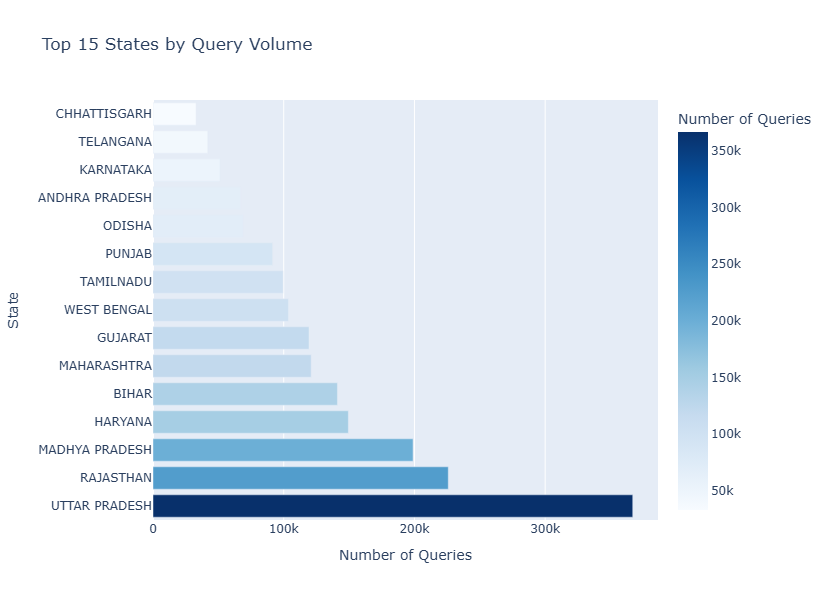


📋 QUERY CATEGORIES
--------------------------------------------------


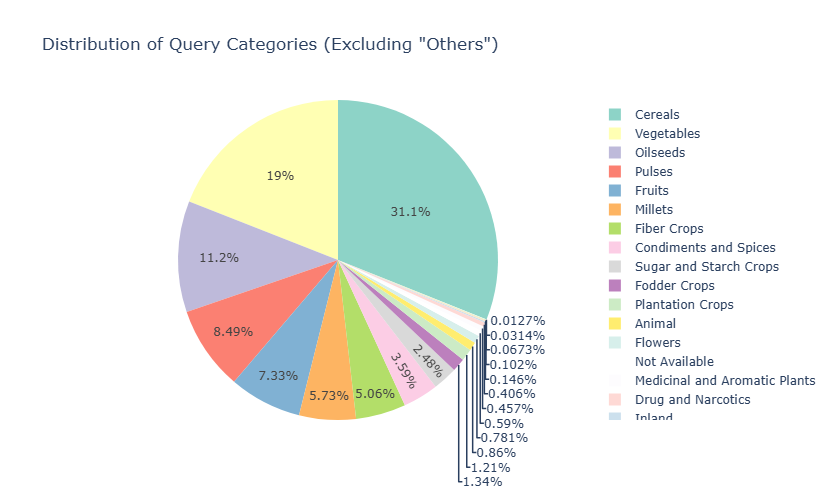


🏭 SECTOR ANALYSIS
--------------------------------------------------


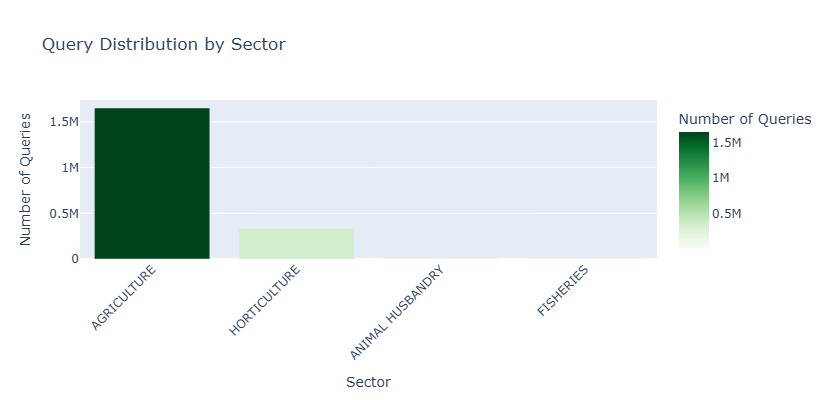


🌱 CROP ANALYSIS
--------------------------------------------------


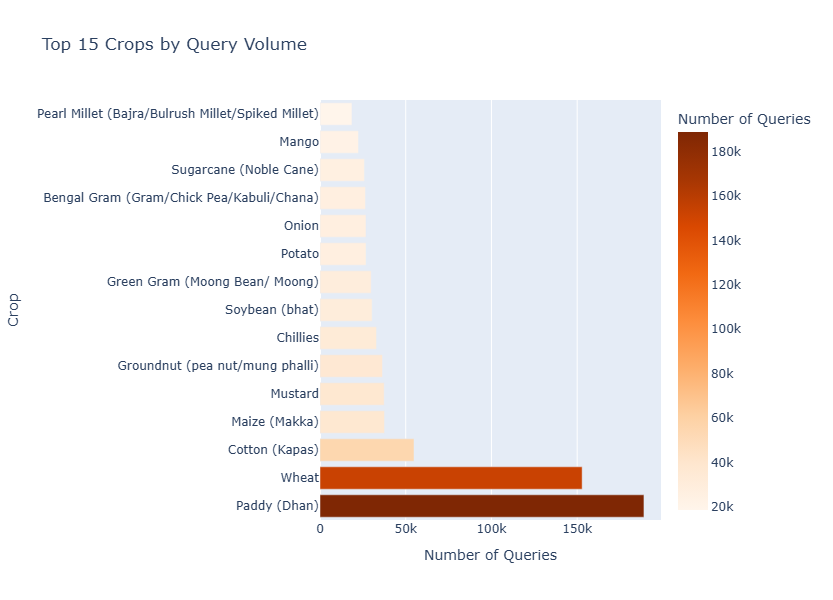


❓ QUERY TYPE ANALYSIS
--------------------------------------------------


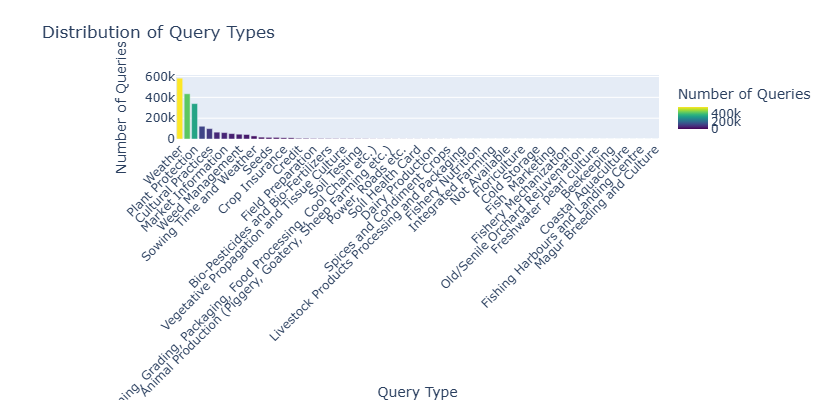

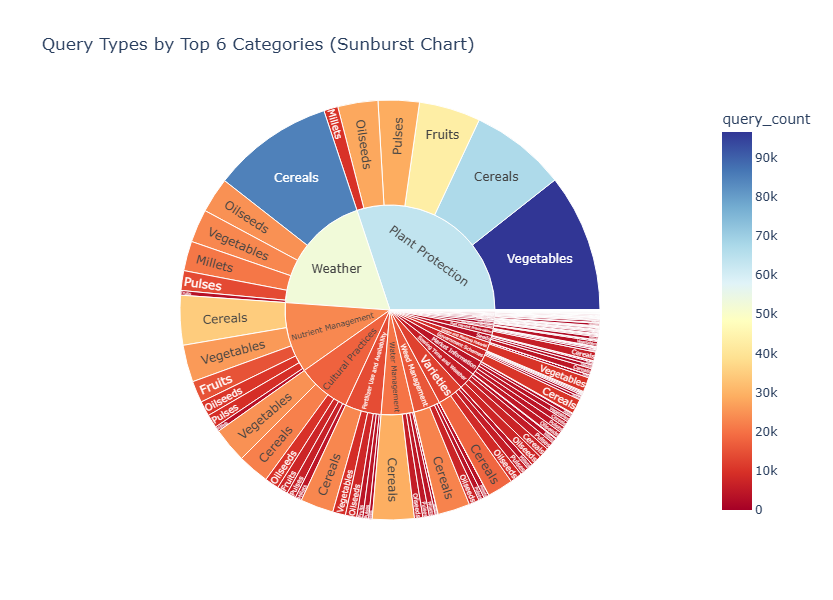


🔥 STATE vs CATEGORY HEATMAP
--------------------------------------------------


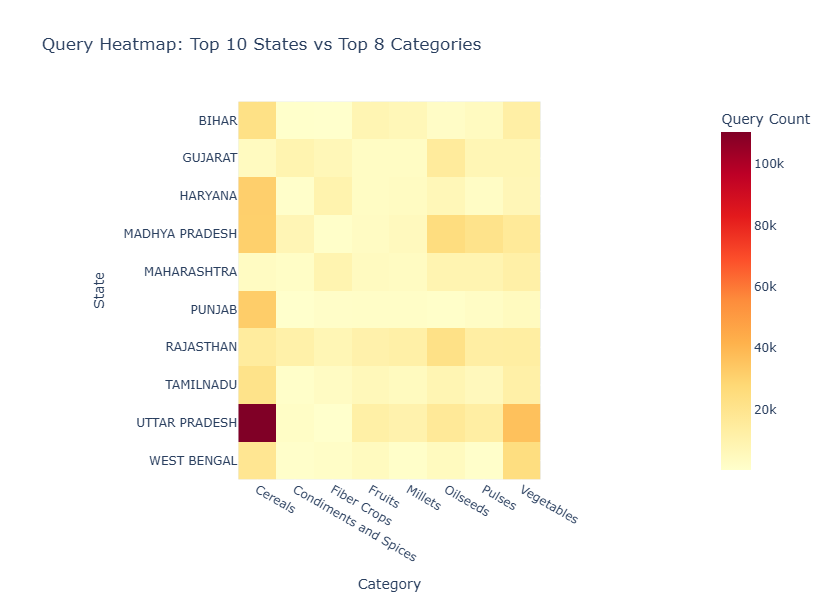


📊 SECTOR vs CATEGORY ANALYSIS
--------------------------------------------------


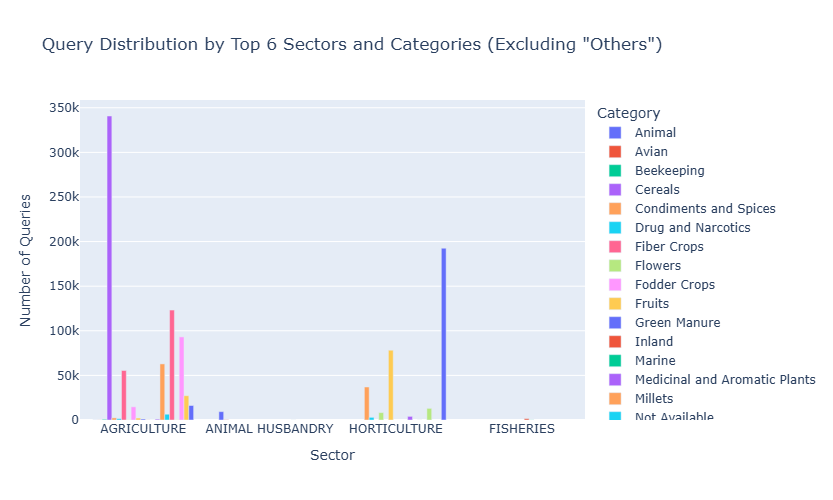


📊 SUMMARY STATISTICS
--------------------------------------------------
                Dimension                   Value
            Total Queries               2,000,000
Average Queries per State                   52632
        Most Active State UTTAR PRADESH (367,000)
             Top Category        Others (902,772)
               Top Sector AGRICULTURE (1,652,674)
        Most Queried Crop  Paddy (Dhan) (188,943)

🎛️ INTERACTIVE FILTERS
--------------------------------------------------
Use the dropdowns below to filter the data:


Output()


📋 DASHBOARD COMPLETE - Data insights generated successfully!

✅ Database connection closed successfully.


In [6]:
# ============================================================================
# KISAN CALL CENTRE (KCC) ANALYTICS DASHBOARD
# ============================================================================

# Dashboard Header
def print_header():
    """Print dashboard header with styling"""
    print("\n" + "="*80)
    print("🌾 KISAN CALL CENTRE (KCC) ANALYTICS DASHBOARD 🌾")
    print("="*80)

# Key Metrics Section
def display_key_metrics(data):
    """Display key performance metrics"""
    print("\n📊 KEY METRICS")
    print("-" * 50)
    
    total_queries = len(data)
    unique_states = data['state_name'].nunique()
    unique_categories = data['category'].nunique()
    unique_sectors = data['sector'].nunique()
    date_range = f"{data['created_on'].min().strftime('%Y-%m-%d')} to {data['created_on'].max().strftime('%Y-%m-%d')}"
    
    metrics_df = pd.DataFrame({
        'Metric': [
            'Total Queries', 
            'States & Union Territories Covered', 
            'Query Categories', 
            'Sectors', 
            'Date Range'
        ],
        'Value': [
            f"{total_queries:,}", 
            unique_states, 
            unique_categories, 
            unique_sectors, 
            date_range
        ]
    })
    
    print(metrics_df.to_string(index=False))
    return total_queries

# Geographic Analysis
def create_geographic_analysis(data):
    """Create geographic distribution visualization"""
    print("\n🗺️ GEOGRAPHIC DISTRIBUTION")
    print("-" * 50)
    
    # Top states by query volume
    state_data = (data.groupby('state_name')
                     .size()
                     .reset_index(name='query_count')
                     .sort_values('query_count', ascending=False)
                     .head(15))
    
    fig = px.bar(
        state_data, 
        x='query_count', 
        y='state_name',
        orientation='h',
        title='Top 15 States by Query Volume',
        labels={'query_count': 'Number of Queries', 'state_name': 'State'},
        color='query_count', 
        color_continuous_scale='Blues'
    )
    
    fig.update_layout(height=600, showlegend=False)
    fig.show()
    
    return state_data

# Category Analysis
def create_category_analysis(data):
    """Create query category distribution visualization"""
    print("\n📋 QUERY CATEGORIES")
    print("-" * 50)
    
    # Filter out 'Others' category for cleaner visualization
    category_data = (data[data['category'] != 'Others']
                        .groupby('category')
                        .size()
                        .reset_index(name='query_count')
                        .sort_values('query_count', ascending=False))
    
    fig = px.pie(
        category_data, 
        values='query_count', 
        names='category',
        title='Distribution of Query Categories (Excluding "Others")',
        color_discrete_sequence=px.colors.qualitative.Set3
    )
    
    fig.update_layout(height=500)
    fig.show()
    
    return category_data

# Sector Analysis
def create_sector_analysis(data):
    """Create sector distribution visualization"""
    print("\n🏭 SECTOR ANALYSIS")
    print("-" * 50)
    
    sector_data = (data.groupby('sector')
                      .size()
                      .reset_index(name='query_count')
                      .sort_values('query_count', ascending=False))
    
    fig = px.bar(
        sector_data, 
        x='sector', 
        y='query_count',
        title='Query Distribution by Sector',
        labels={'sector': 'Sector', 'query_count': 'Number of Queries'},
        color='query_count', 
        color_continuous_scale='Greens'
    )
    
    fig.update_layout(height=400, showlegend=False)
    fig.update_xaxes(tickangle=-45)
    fig.show()
    
    return sector_data

# Crop Analysis
def create_crop_analysis(data):
    """Create crop distribution visualization"""
    print("\n🌱 CROP ANALYSIS")
    print("-" * 50)
    
    # Filter out null/empty/others crops
    crop_data = data[
        data['crop'].notna() & 
        (data['crop'] != '') & 
        (data['crop'] != 'Others')
    ].copy()
    
    if len(crop_data) == 0:
        print("No valid crop data available for analysis.")
        return pd.DataFrame()
    
    crop_counts = (crop_data.groupby('crop')
                            .size()
                            .reset_index(name='query_count')
                            .sort_values('query_count', ascending=False)
                            .head(15))
    
    fig = px.bar(
        crop_counts, 
        x='query_count', 
        y='crop',
        orientation='h',
        title='Top 15 Crops by Query Volume',
        labels={'query_count': 'Number of Queries', 'crop': 'Crop'},
        color='query_count', 
        color_continuous_scale='Oranges'
    )
    
    fig.update_layout(height=600, showlegend=False)
    fig.show()
    
    return crop_counts

# State vs Category Heatmap
def create_state_category_heatmap(data):
    """Create heatmap showing relationship between states and categories"""
    print("\n🔥 STATE vs CATEGORY HEATMAP")
    print("-" * 50)
    
    # Get top states and categories for focused analysis
    top_states = data['state_name'].value_counts().head(10).index
    top_categories = data[data['category'] != 'Others']['category'].value_counts().head(8).index
    
    # Filter and aggregate data
    heatmap_data = (data[
        (data['state_name'].isin(top_states)) & 
        (data['category'].isin(top_categories)) &
        (data['category'] != 'Others')
    ].groupby(['state_name', 'category'])
     .size()
     .reset_index(name='query_count'))
    
    # Create pivot table for heatmap
    heatmap_pivot = heatmap_data.pivot(
        index='state_name', 
        columns='category', 
        values='query_count'
    ).fillna(0)
    
    fig = px.imshow(
        heatmap_pivot, 
        title='Query Heatmap: Top 10 States vs Top 8 Categories',
        labels=dict(x="Category", y="State", color="Query Count"),
        color_continuous_scale='YlOrRd'
    )
    
    fig.update_layout(height=600)
    fig.show()

# Sector vs Category Analysis
def create_sector_category_analysis(data):
    """Create grouped bar chart for sector vs category analysis"""
    print("\n📊 SECTOR vs CATEGORY ANALYSIS")
    print("-" * 50)
    
    # Filter out 'Others' category for cleaner visualization
    sector_cat_data = data[data['category'] != 'Others'].copy()
    
    # Group by sector and category
    sector_cat_group = (sector_cat_data.groupby(['sector', 'category'])
                                      .size()
                                      .reset_index(name='query_count'))
    
    # Filter to top 6 sectors for clarity
    top_sectors = sector_cat_group['sector'].value_counts().index[:6]
    filtered_group = sector_cat_group[sector_cat_group['sector'].isin(top_sectors)]
    
    fig = px.bar(
        filtered_group, 
        x='sector', 
        y='query_count', 
        color='category', 
        barmode='group',
        title='Query Distribution by Top 6 Sectors and Categories (Excluding "Others")',
        labels={'query_count': 'Number of Queries', 'sector': 'Sector', 'category': 'Category'}
    )
    
    fig.update_layout(height=500)
    fig.show()

# Query Type Analysis
def create_query_type_analysis(data):
    """Create query type distribution and cross-analysis visualization"""
    print("\n❓ QUERY TYPE ANALYSIS")
    print("-" * 50)
    
    # Query type distribution
    query_type_data = (data.groupby('query_type')
                          .size()
                          .reset_index(name='query_count')
                          .sort_values('query_count', ascending=False))
    
    fig1 = px.bar(
        query_type_data,
        x='query_type',
        y='query_count',
        title='Distribution of Query Types',
        labels={'query_type': 'Query Type', 'query_count': 'Number of Queries'},
        color='query_count',
        color_continuous_scale='Viridis'
    )
    
    fig1.update_layout(height=400, showlegend=False)
    fig1.update_xaxes(tickangle=-45)
    fig1.show()
    
    # Query type by top categories (excluding 'Others')
    top_categories = data[data['category'] != 'Others']['category'].value_counts().head(6).index
    
    query_cat_data = (data[data['category'].isin(top_categories)]
                         .groupby(['query_type', 'category'])
                         .size()
                         .reset_index(name='query_count'))
    
    fig2 = px.sunburst(
        query_cat_data,
        path=['query_type', 'category'],
        values='query_count',
        title='Query Types by Top 6 Categories (Sunburst Chart)',
        color='query_count',
        color_continuous_scale='RdYlBu'
    )
    
    fig2.update_layout(height=600)
    fig2.show()
    
    return query_type_data

# Summary Statistics
def display_summary_statistics(data, crop_counts):
    """Display comprehensive summary statistics"""
    print("\n📊 SUMMARY STATISTICS")
    print("-" * 50)
    
    # Calculate statistics
    total_queries = len(data)
    avg_queries_per_state = data.groupby('state_name').size().mean()
    most_active_state = data['state_name'].value_counts().index[0]
    most_active_state_count = data['state_name'].value_counts().iloc[0]
    top_category = data['category'].value_counts().index[0]
    top_category_count = data['category'].value_counts().iloc[0]
    top_sector = data['sector'].value_counts().index[0]
    top_sector_count = data['sector'].value_counts().iloc[0]
    
    # Handle crop data
    if not crop_counts.empty:
        most_queried_crop = f"{crop_counts.iloc[0]['crop']} ({crop_counts.iloc[0]['query_count']:,})"
    else:
        most_queried_crop = "N/A"
    
    summary_stats = pd.DataFrame({
        'Dimension': [
            'Total Queries', 
            'Average Queries per State', 
            'Most Active State', 
            'Top Category', 
            'Top Sector', 
            'Most Queried Crop'
        ],
        'Value': [
            f"{total_queries:,}",
            f"{avg_queries_per_state:.0f}",
            f"{most_active_state} ({most_active_state_count:,})",
            f"{top_category} ({top_category_count:,})",
            f"{top_sector} ({top_sector_count:,})",
            most_queried_crop
        ]
    })
    
    print(summary_stats.to_string(index=False))

# Interactive Filters Section
def create_interactive_filters(data):
    """Create interactive filtering widgets"""
    print("\n🎛️ INTERACTIVE FILTERS")
    print("-" * 50)
    
    # Create dropdown options
    state_options = ['All'] + sorted(data['state_name'].unique().tolist())
    category_options = ['All'] + sorted(data['category'].unique().tolist())
    year_options = ['All'] + sorted(data['year'].unique().tolist())
    
    # Create widgets
    state_dropdown = widgets.Dropdown(
        options=state_options,
        value='All',
        description='State:',
        style={'description_width': 'initial'}
    )
    
    category_dropdown = widgets.Dropdown(
        options=category_options,
        value='All',
        description='Category:',
        style={'description_width': 'initial'}
    )
    
    year_dropdown = widgets.Dropdown(
        options=year_options,
        value='All',
        description='Year:',
        style={'description_width': 'initial'}
    )
    
    output = widgets.Output()
    
    def update_filtered_data(*args):
        """Update display based on filter selections"""
        with output:
            clear_output(wait=True)
            
            # Apply filters
            filtered_data = data.copy()
            
            if state_dropdown.value != 'All':
                filtered_data = filtered_data[filtered_data['state_name'] == state_dropdown.value]
            
            if category_dropdown.value != 'All':
                filtered_data = filtered_data[filtered_data['category'] == category_dropdown.value]
            
            if year_dropdown.value != 'All':
                filtered_data = filtered_data[filtered_data['year'] == int(year_dropdown.value)]
            
            # Display filtered results
            print(f"🔍 Filtered Results: {len(filtered_data):,} queries")
            
            if len(filtered_data) > 0:
                print(f"\n📈 Top Categories in Filtered Data:")
                top_cats = filtered_data['category'].value_counts().head(5)
                for cat, count in top_cats.items():
                    print(f"  • {cat}: {count:,} queries")
                
                print(f"\n🏭 Top Sectors in Filtered Data:")
                top_sectors = filtered_data['sector'].value_counts().head(3)
                for sector, count in top_sectors.items():
                    print(f"  • {sector}: {count:,} queries")
            else:
                print("❌ No data matches the selected filters.")
    
    # Set up event handlers
    state_dropdown.observe(update_filtered_data, names='value')
    category_dropdown.observe(update_filtered_data, names='value')
    year_dropdown.observe(update_filtered_data, names='value')
    
    # Display widgets
    print("Use the dropdowns below to filter the data:")
    display(widgets.HBox([state_dropdown, category_dropdown, year_dropdown]))
    display(output)
    
    # Initial display
    update_filtered_data()

# Main Dashboard Function
def run_kcc_dashboard(master_data):
    """Execute the complete KCC Analytics Dashboard"""
    
    # Print header
    print_header()
    
    # Display key metrics
    total_queries = display_key_metrics(master_data)
    
    # Create all visualizations
    state_data = create_geographic_analysis(master_data)
    category_data = create_category_analysis(master_data)
    sector_data = create_sector_analysis(master_data)
    crop_counts = create_crop_analysis(master_data)
    query_type_data = create_query_type_analysis(master_data)
    create_state_category_heatmap(master_data)
    create_sector_category_analysis(master_data)
    
    # Display summary statistics
    display_summary_statistics(master_data, crop_counts)
    
    # Create interactive filters
    create_interactive_filters(master_data)
    
    # Footer
    print("\n" + "="*80)
    print("📋 DASHBOARD COMPLETE - Data insights generated successfully!")
    print("="*80)

# Execute Dashboard
if 'master' in locals():
    run_kcc_dashboard(master)
    
    # Close database connection if it exists
    if 'con' in locals():
        con.close()
        print(f"\n✅ Database connection closed successfully.")
else:
    print("Please ensure 'master' DataFrame is loaded before running the dashboard.")